# Model Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from pathlib import Path
import subprocess, h5py, os, time as _time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# â”€â”€ USER CONTROL: change this to sweep the resolution limit â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
scatterer_spacing_m = 0.20   # lateral separation between two PEC scatterers [m]
                              # try: 0.20, 0.15, 0.10, 0.08, 0.06, 0.04
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns  â‰ˆ 0.16892
f_c_GHz    = 1.5                             # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                 # m  â‰ˆ 0.1126
v_mig      = v_ice / 2                       # exploding-reflector half-velocity [m/ns]
t0_ns      = 0.953                           # gprMax Ricker peak delay [ns]

# gprMax grid (30 cells per min wavelength in ice)
dx_grid = 7.454e-4   # m  = 0.7454 mm

# Simulation domain (2D TMy: dy = dx_grid exactly â€” one cell thick)
domain_x    = 4.0    # m
domain_z    = 0.8    # m
time_window = 15e-9  # s

# Zero-offset B-scan survey
x_survey_start = 0.5    # m  (first trace midpoint)
x_survey_end   = 3.5    # m  (last  trace midpoint)
n_cells_step   = 15     # grid cells per trace â†’ spacing â‰ˆ Î»/10
trace_spacing  = n_cells_step * dx_grid           # m  â‰ˆ 0.01118
n_traces = int(round((x_survey_end - x_survey_start) / trace_spacing)) + 1
x_traces = x_survey_start + np.arange(n_traces) * trace_spacing   # [m]

# Scatterer targets
x_s1   = 2.0
x_s2   = x_s1 + scatterer_spacing_m
z_scat = 0.5   # depth of both scatterers [m]

# Migration image grid
x_img = np.linspace(x_survey_start, x_survey_end, 300)
z_img = np.linspace(0.0, domain_z, 120)

rayleigh_m = wavelength / 2

# Paths
BASE          = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks')
DATA          = BASE / 'B_Scan_Migration_data'
DATA.mkdir(exist_ok=True)
psf_in_path   = DATA / 'psf_bscan.in'
bg_in_path    = DATA / 'bg_bscan.in'
psf_out_path  = DATA / 'psf_bscan_merged.out'
bg_out_path   = DATA / 'bg_bscan_merged.out'
GPRMAX_PYTHON = r'C:\Users\Administrator\miniconda3\envs\gprMax\python.exe'

print(f'Î»_ice          = {wavelength*1e3:.1f} mm')
print(f'Rayleigh limit = {rayleigh_m*1e3:.1f} mm  (Î»/2)')
print(f'v_ice          = {v_ice:.5f} m/ns,   v_mig = v/2 = {v_mig:.5f} m/ns')

Î»_ice          = 112.6 mm
Rayleigh limit = 56.3 mm  (Î»/2)
v_ice          = 0.16891 m/ns,   v_mig = v/2 = 0.08446 m/ns


In [2]:
wavelength = v_ice / f_c_GHz
wavelength / 0.002

np.float64(56.304638092048904)

In [3]:
x_scatterer_1 = (2 - 1 * wavelength)
x_scatterer_2 = (2 + 1 * wavelength)
y_scatterer_1_2 = 0.9 - wavelength * 6 # farfield scatterer depth (to avoid near-field effects)
radius_scatterer = wavelength / 10

In [4]:
x_scatterer_1, x_scatterer_2

(np.float64(1.8873907238159022), np.float64(2.1126092761840978))

In [42]:
(x_scatterer_2 - x_scatterer_1) / wavelength

np.float64(5.999999999999998)

In [43]:
# timelapsed x_scatterer_1
x_scatterer_1 + 2 * wavelength

np.float64(1.8873907238159022)

# Data Creation

In [44]:
radius_scatterer

np.float64(0.011260927618409782)

In [45]:
(3.9 - 0.100) / 380

0.01

In [46]:
%%writefile timelapse_study/baseline/baseline.in

#title: GPR Timelapse Study - baseline
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.662 0.224 0 1.662 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 baseline n
#messages: y

In [47]:
%%writefile timelapse_study/shift_2lambda/resolution_2lambda.in

#title: GPR Timelapse Study - 2 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.887 0.224 0 1.887 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_2_lambda n
#messages: y

In [48]:
# timelapsed x_scatterer_1
x_scatterer_1 + 1 * wavelength, x_scatterer_2

(np.float64(1.7747814476318045), np.float64(2.3378278285522933))

In [49]:
%%writefile timelapse_study/shift_1lambda/resolution_1lambda.in

#title: GPR Timelapse Study - 1 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.775 0.224 0 1.775 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_1_lambda n
#messages: y

In [50]:
# timelapsed x_scatterer_1
x_scatterer_1 + 0.5 * wavelength, x_scatterer_2

(np.float64(1.7184768095397556), np.float64(2.3378278285522933))

In [51]:
%%writefile timelapse_study/shift_0p5lambda/resolution_0p5lambda.in

#title: GPR Timelapse Study - 0.5 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.718 0.224 0 1.718 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p5_lambda n
#messages: y

In [52]:
# timelapsed x_scatterer_1
x_scatterer_1 + 0.25 * wavelength, x_scatterer_2

(np.float64(1.6903244904937311), np.float64(2.3378278285522933))

In [53]:
%%writefile timelapse_study/shift_0p25lambda/resolution_0p25lambda.in

#title: GPR Timelapse Study - 0.25 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.690 0.224 0 1.690 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p25_lambda n
#messages: y

In [54]:
# timelapsed x_scatterer_1
x_scatterer_1 + 1/8 * wavelength, x_scatterer_2

(np.float64(1.676248330970719), np.float64(2.3378278285522933))

In [55]:
%%writefile timelapse_study/shift_0p125lambda/resolution_0p125lambda.in

#title: GPR Timelapse Study - 0.125 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.676 0.224 0 1.676 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p125_lambda n
#messages: y

In [56]:
# timelapsed x_scatterer_1
x_scatterer_1 + 1/16 * wavelength, x_scatterer_2

(np.float64(1.6692102512092128), np.float64(2.3378278285522933))

In [57]:
%%writefile timelapse_study/shift_0p0625lambda/resolution_0p0625lambda.in

#title: GPR Timelapse Study - 0.0625 wavelength shift
#domain: 4.000 1.000 0.002
#dx_dy_dz: 0.002 0.002 0.002
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.002 ice

// Two point scatterers (PEC)
#cylinder: 1.669 0.224 0 1.669 0.224 0.002 0.0113 pec
#cylinder: 2.338 0.224 0 2.338 0.224 0.002 0.0113 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.002 0.002 0.002 0.002 two_point_scatterers_0p0625_lambda n
#messages: y

# Loading in the data

In [5]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [6]:
background_data  = r'resolution_study/background/resolution_background_merged.out'
two_lambda_data  = r'resolution_study/study_2lambda/resolution_2lambda_merged.out'
one_lambda_data  = r'resolution_study/study_1lambda/resolution_1lambda_merged.out'
half_lambda_data = r'resolution_study/study_0p5lambda/resolution_0p5lambda_merged.out'
quarter_lambda_data = r'resolution_study/study_0p25lambda/resolution_0p25lambda_merged.out'
eighth_lambda_data = r'resolution_study/study_0p125lambda/resolution_0p125lambda_merged.out'

rxnumber = 1
rxcomponent = 'Ez'

output_background, dt_background = get_output_data(background_data, rxnumber, rxcomponent)
output_two_lambda, dt_two_lambda = get_output_data(two_lambda_data, rxnumber, rxcomponent)
output_one_lambda, dt_one_lambda = get_output_data(one_lambda_data, rxnumber, rxcomponent)
output_half_lambda, dt_half_lambda = get_output_data(half_lambda_data, rxnumber, rxcomponent)
output_quarter_lambda, dt_quarter_lambda = get_output_data(quarter_lambda_data, rxnumber, rxcomponent)
output_eighth_lambda, dt_eighth_lambda = get_output_data(eighth_lambda_data, rxnumber, rxcomponent)

output_two_lambda = output_two_lambda - output_background
output_one_lambda = output_one_lambda - output_background
output_half_lambda = output_half_lambda - output_background
output_quarter_lambda = output_quarter_lambda - output_background
output_eighth_lambda = output_eighth_lambda - output_background

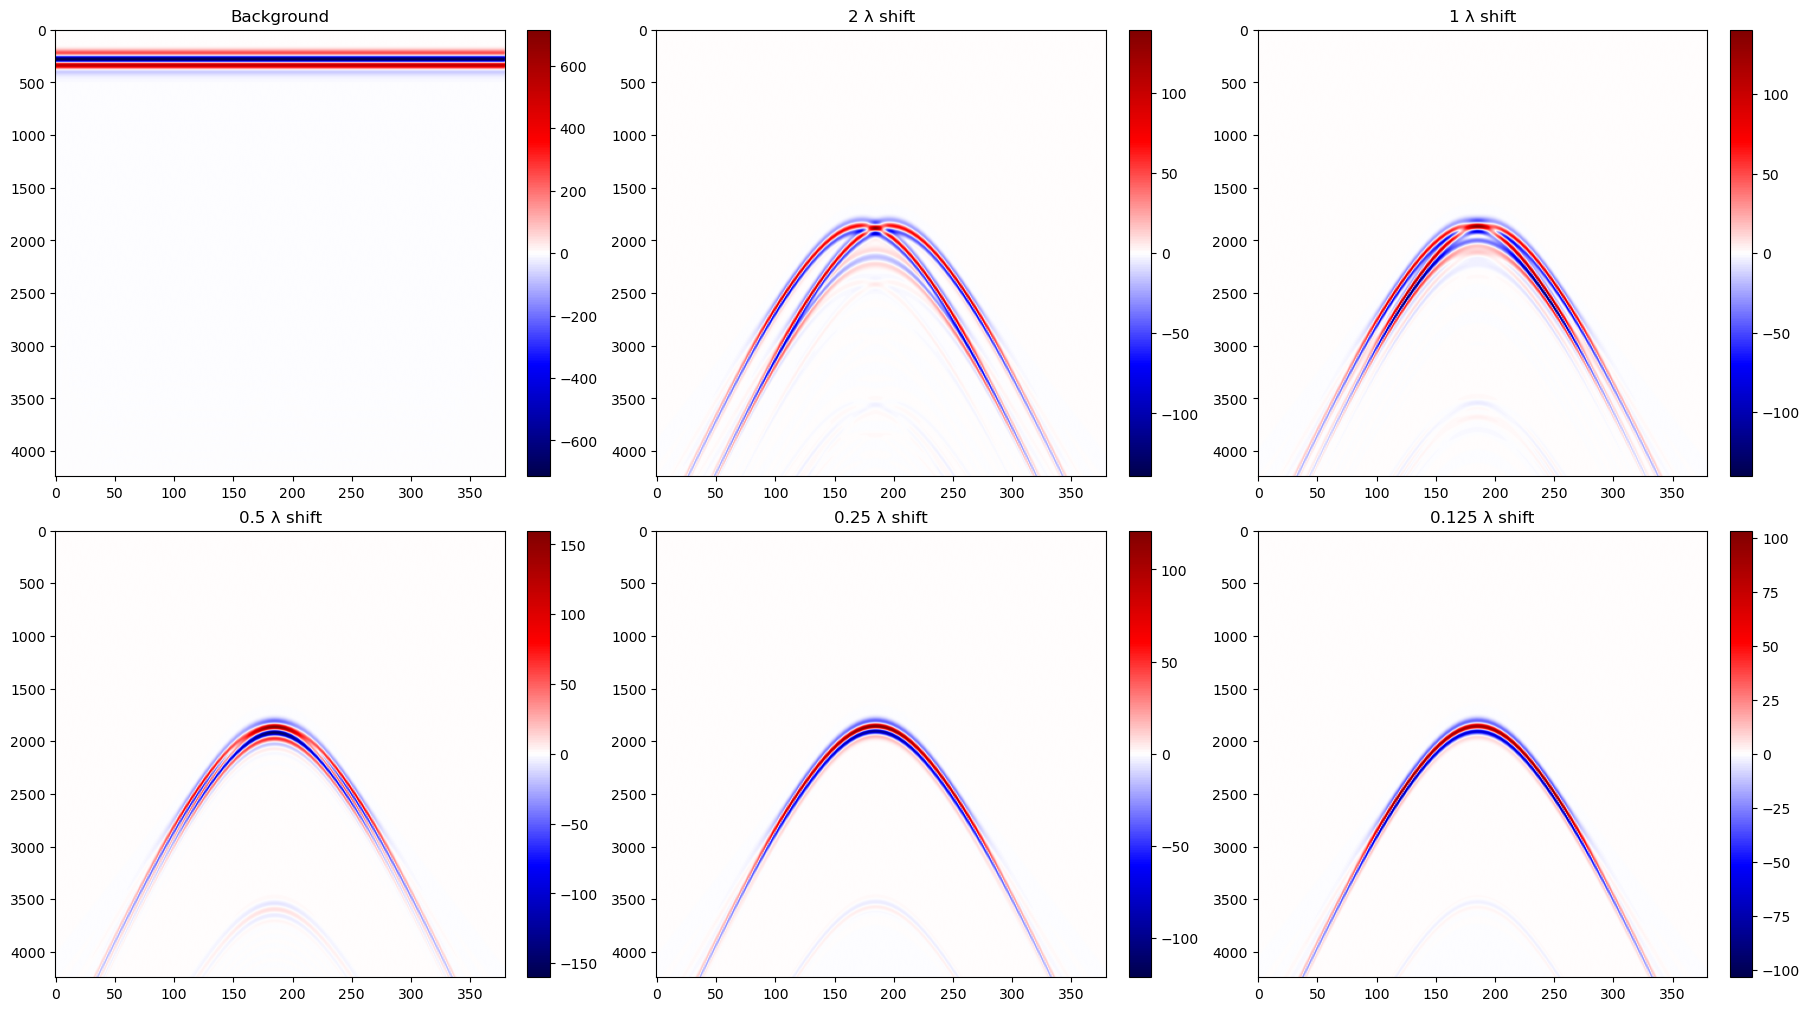

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

plots = [
    ("Background", output_background),
    ("2 λ shift", output_two_lambda),
    ("1 λ shift", output_one_lambda),
    ("0.5 λ shift", output_half_lambda),
    ("0.25 λ shift", output_quarter_lambda),
    ("0.125 λ shift", output_eighth_lambda),
]

for ax, (title, data) in zip(axes.ravel(), plots):
    im = ax.imshow(
        data,
        cmap="seismic",
        aspect="auto",
        vmin=-np.max(np.abs(data)),
        vmax=np.max(np.abs(data)),
    )
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

plt.show()

# Kirchhoff Migration

In [16]:
def PylopsKirchoffMigration(data, t, x, vel_model, z,wav='Ricker', wavcenter='Center',f0=0.08 ,recs = None, srcs = None, mode='analytic', dynamic=False,
aperture=None, angleaperture=None, return_op=False):
    """
    Perform Kirchhoff migration using PyLops zero offset operator. pass ns, gHz and meter 
    """
    import numpy as np
    import KirchhoffPylopsZeroOffset
    import importlib
    importlib.reload(KirchhoffPylopsZeroOffset)
    from pylops.utils.wavelets import ricker
    
    # For zero-offset, srcs = recs
    rx = x
    rz = np.zeros_like(rx)
    recs = np.vstack((rx, rz))
    srcs = recs

    # Handle wavelet selection
    if wav == 'Ricker':
        # Generate a short wavelet: 6 cycles, centered at zero, dependent on f0
        n_cycles = 6
        period_ns = 1.0 / f0 # t in ns, f0 in GHz
        wav_duration = n_cycles * period_ns # total duration in ns
        n_wav_samples = int(np.ceil(wav_duration / (t[1] - t[0])))
        # Ensure odd number for center
        if n_wav_samples % 2 == 0:
            n_wav_samples += 1
        wav_arr, trick, wcenter = ricker(t[0:n_wav_samples], f0=f0)
    else:
        wav_arr = wav
        
    if wavcenter == 'Center':
        wavcenter = wcenter

    # Build Zero Offset Kirchhoff operator
    K = KirchhoffPylopsZeroOffset.Kirchhoff(
        z=z, x=x, t=t,
        srcs=srcs, recs=recs,
        vel=vel_model,
        wav=wav_arr, wavcenter=wavcenter,
        mode=mode, dynamic=dynamic,
        aperture=aperture, angleaperture=angleaperture
    )

    d = data.flatten()
    print("d.shape:", d.shape, "K dimension:", K.shape)

    # Migrate: apply adjoint
    m = K.H @ d
    
    # Reshape to (nz, nx)
    m = m.reshape(len(x), len(z)).T
    
    if return_op:
        return m, K
    return m

In [17]:
def kirchhoff_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns):
    """
    Post-stack zero-offset Kirchhoff delay-and-sum.

    Image(x, z) = Î£_tr  bscan[tr, t(x, z, x_tr)]
    t = r / v_mig + t0,   r = sqrt((x - x_tr)^2 + z^2)

    Uses linear interpolation between adjacent time samples.
    Returns image (n_z, n_x), normalised to peak = 1.
    """
    n_tr, n_t = bscan.shape
    image = np.zeros((len(z_img), len(x_img)))

    # Aperture / obliquity parameters
    max_angle_deg = 40.0
    tan_max = np.tan(np.radians(max_angle_deg))

    tr_idx = np.arange(n_tr)

    # Perform delay-and-sum with obliquity weighting and aperture limit.
    for iz, z in enumerate(z_img):
        if z == 0.0:
            continue

        dx = x_img[:, None] - x_traces[None, :]     # (n_x, n_tr)
        r  = np.sqrt(dx**2 + z**2)

        # Two-way travel time (using v_mig per docstring)
        t  = r / v_mig + t0_ns                       # (n_x, n_tr) [ns]

        i_frac = t / dt_ns
        i0 = np.clip(i_frac.astype(int), 0, n_t - 2)
        frac = i_frac - i0
        i1 = np.minimum(i0 + 1, n_t - 1)

        # Linear interpolation in time
        samp = ((1 - frac) * bscan[tr_idx[None, :], i0]
               +     frac  * bscan[tr_idx[None, :], i1])  # (n_x, n_tr)

        # Aperture mask: allow only traces within semi-aperture angle
        aperture_mask = (np.abs(dx) <= (z * tan_max)).astype(float)

        # Obliquity factor (cosine of incidence angle)
        obliquity = np.where(r > 0, z / r, 1.0)

        # Apply weights and sum
        samp *= (obliquity * aperture_mask)
        image[iz] = samp.sum(axis=1)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)

In [10]:
# â”€â”€ Taper parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
taper_end_ns   = 14.0   # cosine ramp at the END of each trace [ns]  â†’  zeros hyperbola tails
taper_decay_ns = 1   # exponential decay time constant [ns]        â†’  emphasises apices

def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1â†’0 over the last taper_samples."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay: 1.0 at t=0, decays toward 0 with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

In [11]:

ANGLE_AP = 40   # half-aperture [degrees] â€” applied identically to both methods
STUDY_ROOT = BASE / 'resolution_study'

In [13]:
x_scatterer_1 = (2 - 1 * wavelength)
x_scatterer_2 = (2 + 1 * wavelength)
y_scatterer_1_2 = 0.9 - wavelength * 6 # farfield scatterer depth (to avoid near-field effects)
radius_scatterer = wavelength / 10

In [14]:
# ── Kirchhoff on output_two_lambda_no_background ──────────────────────────────
_raw = output_two_lambda
dt_ns_2lam = dt_two_lambda * 1e9   # dt from get_output_data, in seconds

# Normalise to (n_tr, n_t)
if _raw.shape[0] > _raw.shape[1]:
    _data_trnt = _raw.T
else:
    _data_trnt = _raw.copy()

n_tr_2lam, n_t_2lam = _data_trnt.shape
time_ns_2lam = np.arange(n_t_2lam) * dt_ns_2lam

# Bistatic geometry: Tx at curr_x, Rx at curr_x + 0.1 m (from .in file)
# Zero-offset migration requires MIDPOINT positions (apex of bistatic hyperbola
# is at the midpoint, not at the source position).
_rx_offset    = 0.1                      # m  (Rx offset from Tx)
x_traces_2lam = (0.1 + _rx_offset / 2) + np.arange(n_tr_2lam) * 0.01   # midpoints [m]

# Scatterer geometry
z_scat_2lam  = 0.9 - y_scatterer_1_2    # cylinder centre depth [m]
z_star_2lam  = z_scat_2lam - radius_scatterer   # top of cylinder (first reflection) [m]

# depth image grid (0 → 0.8 m covers z_scat_2lam ≈ 0.676 m)
z_img_2lam = np.linspace(0.0, 0.8, 160)

print(f'raw={_raw.shape}  → (n_tr, n_t)={_data_trnt.shape}')
print(f'dt={dt_ns_2lam:.6f} ns,  t_max={time_ns_2lam[-1]:.2f} ns')
print(f'x_traces_2lam (midpoints): {x_traces_2lam[0]:.3f} → {x_traces_2lam[-1]:.3f} m  ({n_tr_2lam} traces)')
print(f'z_scat_2lam (centre) = {z_scat_2lam:.3f} m,  z_star_2lam (top) = {z_star_2lam:.4f} m')

# ── Taper ────────────────────────────────────────────────────────────────────
n_tap_2lam   = int(round(taper_end_ns / dt_ns_2lam))
w_end_2lam   = make_end_taper(n_t_2lam, n_tap_2lam)
w_decay_2lam = make_decay_taper(time_ns_2lam, taper_decay_ns)
_data_tapered = _data_trnt * (w_end_2lam * w_decay_2lam)[np.newaxis, :]

# t0 shift for PyLops
_t0_samp_2lam = int(round(t0_ns / dt_ns_2lam))
_shifted_2lam = np.roll(_data_tapered, -_t0_samp_2lam, axis=1)
_shifted_2lam[:, -_t0_samp_2lam:] = 0.0

# ── DAS Kirchhoff ─────────────────────────────────────────────────────────────
_t = _time.perf_counter()
kh_das_2lam = kirchhoff_poststack(
    _data_tapered, dt_ns_2lam,
    x_traces_2lam, v_mig, x_traces_2lam, z_img_2lam, t0_ns
)
print(f'DAS Kirchhoff: {_time.perf_counter()-_t:.1f} s  shape={kh_das_2lam.shape}')

# ── PyLops Kirchhoff ──────────────────────────────────────────────────────────
_t = _time.perf_counter()
kh_pylops_2lam, _ = PylopsKirchoffMigration(
    _shifted_2lam, time_ns_2lam, x_traces_2lam,
    v_ice, z_img_2lam,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True,
)
print(f'PyLops Kirchhoff: {_time.perf_counter()-_t:.1f} s  shape={kh_pylops_2lam.shape}')

# ── Plot ─────────────────────────────────────────────────────────────────────
_methods_2lam = [
    (kh_das_2lam,    'DAS  (kirchhoff_poststack)\nv_mig = v_ice/2,  t0 in formula'),
    (kh_pylops_2lam, f'PyLops Kirchhoff\nv_ice (t0-shifted),  aperture={ANGLE_AP}°'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                     '_zoomed'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, (img, label) in zip(axes, _methods_2lam):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1], z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' — zoomed' if tag else ''
    fig.suptitle(
        f'Kirchhoff on output_two_lambda_no_background{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m (cyl. top)',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'kirchhoff_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


raw=(4241, 380)  → (n_tr, n_t)=(380, 4241)
dt=0.004717 ns,  t_max=20.00 ns
x_traces_2lam (midpoints): 0.150 → 3.940 m  (380 traces)
z_scat_2lam (centre) = 0.676 m,  z_star_2lam (top) = 0.6644 m


NameError: name 'kirchhoff_poststack' is not defined

# Gazdag

In [101]:
def gazdag_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns,
                     f_min_GHz=0.3, f_max_GHz=3.0):
    """
    Standard Gazdag phase-shift migration for zero-offset post-stack data.

    No source-side correction (unlike CSG shot-profile Gazdag).
    Uses v_mig = v/2 (exploding-reflector half-velocity) in kz.

    Steps:
    1. 2D FFT of tapered bscan (2x spatial zero-padding).
    2. Bandpass to signal frequencies (f_min to f_max GHz) â€” removes
       out-of-band bins that would otherwise dominate the depth sum.
    3. t0 phase correction: D *= exp(+i.omega.t0) to remove Ricker peak delay.
    4. Depth loop: D *= exp(+i.kz.dz),  kz = sqrt((omega/v_mig)^2 - kx^2).
       Evanescent components (kz^2 <= 0) zeroed throughout.
    5. Imaging: image[z] = Re{ IFFT_kx{ sum_omega D } }  (t = 0 condition).
    6. Bilinear interpolation to x_img grid.
    """
    n_tr, n_t = bscan.shape
    dx_tr = float(x_traces[1] - x_traces[0])
    n_pad = 2 * n_tr   # 2x spatial zero-padding
    n_t_pad = 2 * n_t  # 2x temporal zero-padding

    # Spatial cosine taper (5% each edge)
    taper = np.ones(n_tr)
    nb = max(1, int(0.05 * n_tr))
    taper[:nb]  = 0.5 * (1 - np.cos(np.pi * np.arange(nb) / nb))
    taper[-nb:] = taper[:nb][::-1]

    # 2D FFT  ->  shape (n_pad, n_t)
    D = np.fft.fft2(bscan * taper[:, None], s=(n_pad, n_t))
    f_arr  = np.fft.fftfreq(n_t, dt_ns)           # GHz (dt in ns -> f in 1/ns = GHz)
    omega  = 2 * np.pi * f_arr                     # rad/ns
    kx     = 2 * np.pi * np.fft.fftfreq(n_pad, dx_tr)  # rad/m

    # Bandpass: zero frequency bins outside signal band
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[:, ~band] = 0.0
    print(f'  Bandpass: {band.sum()} of {n_t} freq bins kept '
          f'({f_min_GHz}-{f_max_GHz} GHz)')

    # t0 correction: advance phase to align wavelet peak with geometric TWTT
    D *= np.exp(1j * omega[None, :] * t0_ns) 

    # Dispersion with half-velocity (exploding reflector)
    kz2 = (omega[None, :] / v_mig)**2 - kx[:, None]**2  # (n_pad, n_t)
    kz  = np.where(kz2 > 0, np.sqrt(np.maximum(kz2, 0.0)), 0.0)
    D[:, ~band] = 0.0   # re-apply after t0 shift
    D[kz2 <= 0] = 0.0   # zero evanescent before depth loop

    image  = np.zeros((len(z_img), n_pad))
    z_prev = 0.0

    for iz, z in enumerate(z_img):
        dz = z - z_prev
        if dz > 0:
            D *= np.exp(1j * kz * dz)   # downward continuation
            D[kz2 <= 0] = 0.0           # re-apply evanescent mask
        # Imaging condition: IFFT_kx then sum over omega (= evaluate at t = 0)
        D_x = np.fft.ifft(D, axis=0)   # (n_pad, n_t)
        image[iz] = np.real(D_x.sum(axis=1))
        z_prev = z

    # x-axis of zero-padded FFT and interpolation to output grid
    x_fft   = x_traces[0] + np.arange(n_pad) * dx_tr
    img_out = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img_out[iz] = np.interp(x_img, x_fft, image[iz])

    peak = np.max(np.abs(img_out))
    return img_out / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_ps = gazdag_poststack(bscan_sc, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns)
# print(f'Gazdag done in {_time.perf_counter()-t0_perf:.1f} s  |  shape: {img_ps.shape}')


In [102]:
import time as _time

def gazdag_phaseshift_pylops1(data, x, t, z, vel,
                              f_min_GHz=0.2, f_max_GHz=3.0):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    Direct f-kx implementation â€” no PyLops PhaseShift black box.

      kz = sqrt( max(0, (omega/v_mig)^2 - kx^2) )
      depth loop: D *= exp(i * kz * dz),  D[evanescent] = 0  after every step

    PyLops PhaseShift clamps evanescent kz to 0 (pass-through, not kill),
    so those bins accumulate at the t=0 imaging condition over many depth
    steps and produce upside-down parabola ('smile') artefacts.
    Re-zeroing explicitly after each step prevents any accumulation.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly spaced from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (nz, nx), peak-normalised to Â±1.
    """
    nt, nx = data.shape
    dt = float(t[1] - t[0])
    dx = float(x[1] - x[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # Spatial cosine taper (5 %) + 100 % symmetric zero-pad
    n_tap = max(3, int(0.05 * nx))
    pad   = nx             # nx zeros each side â†’ nx_pad = 3 nx
    sp_tap          = np.ones(nx)
    sp_tap[:n_tap]  = 0.5 * (1 - np.cos(np.pi * np.arange(n_tap) / n_tap))
    sp_tap[-n_tap:] = sp_tap[:n_tap][::-1]
    data_padded = np.pad(data * sp_tap[None, :],
                         ((0, 0), (pad, pad)), mode='constant')  # (nt, nx_pad)
    nx_pad = nx + 2 * pad

    # 2-D FFT â†’ (f, kx) domain
    D = np.fft.fft2(data_padded)                    # (nt, nx_pad)

    f_arr = np.fft.fftfreq(nt, dt)                  # [GHz]
    kx    = 2 * np.pi * np.fft.fftfreq(nx_pad, dx)  # [rad/m]
    omega = 2 * np.pi * f_arr                        # [rad/ns]

    # Bandpass â€” removes DC/near-DC and above-signal noise
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[~band, :] = 0.0

    # Dispersion + evanescent mask (computed once, applied every step)
    kz2       = (omega[:, None] / v_mig)**2 - kx[None, :]**2  # (nt, nx_pad)
    kz        = np.sqrt(np.maximum(kz2, 0.0))
    evan_mask = kz2 <= 0
    D[evan_mask] = 0.0      # zero evanescent before depth loop

    print(f'  nx={nx} â†’ nx_pad={nx_pad}  (+{2*pad} spatial zeros)')
    print(f'  Bandpass: {band.sum()}/{nt} bins kept  '
          f'({f_min_GHz:.1f}â€“{f_max_GHz:.1f} GHz)')
    print(f'  Evanescent bins: {evan_mask.sum()}/{evan_mask.size}'
          f' ({100*evan_mask.mean():.1f}%)')

    # Depth loop
    image  = np.zeros((len(z), nx_pad))
    z_prev = 0.0

    for iz, zi in enumerate(z):
        dz_step = zi - z_prev
        if dz_step > 0:
            D *= np.exp(1j * kz * dz_step)
            D[evan_mask] = 0.0    # re-zero evanescent after every step
        # Imaging condition: IFFT over kx (axis 1), sum over Ï‰ (axis 0) = t=0
        image[iz] = np.real(np.fft.ifft(D, axis=1).sum(axis=0))
        z_prev = zi

    # Trim symmetric spatial padding
    image = image[:, pad:-pad]
    peak  = np.max(np.abs(image))
    return image / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_syn_ps = gazdag_phaseshift_pylops1(data_synth, x_syn, t_syn, z_syn, v_syn)
# print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
#       f'  |  shape: {img_syn_ps.shape}')

In [103]:
import pylops
import time as _time

def gazdag_phaseshift_pylops2(data, x, t, z, vel):
    """
    Gazdag phase-shift migration using pylops.waveeqprocessing.PhaseShift.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly sampled from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Pre-processing
    --------------
    1. Spatial cosine taper (5 % each edge) + 100 % zero-pad each side.
    2. f-kx dip filter: zero every (f, kx) bin where |kx| > |f| / v_mig.
       PyLops PhaseShift uses sqrt(max(kzÂ², 0)) so evanescent bins (kz = 0)
       pass through unchanged at every depth step â€” without this filter they
       accumulate at t = 0 and create upside-down parabola ('smile') artefacts.

    Returns image (nz, nx), peak-normalised to Â±1.
    """
    nt, nx = data.shape
    dt  = float(t[1] - t[0])
    dx  = float(x[1] - x[0])
    dz  = float(z[1] - z[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # â”€â”€ Spatial cosine taper + 100 % zero-pad on each side â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    n_xtap  = max(3, int(0.05 * nx))
    pad     = 2 * nx         # nx zeros each side â†’ nx_pad = 3 nx
    taper   = pylops.utils.tapers.taper2d(nt, nx, n_xtap)   # (nx, nt)
    data_sp = np.pad(
        data.T * taper,             # (nx, nt)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                               # (nx_pad, nt)
    nx_pad = nx + 2 * pad

    # â”€â”€ f-kx dip filter: kill evanescent bins before migration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Forward transform: rfft in time, then full fft in space
    D_fk     = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)   # (nx_pad, nf)
    freq_arr = np.fft.rfftfreq(nt, dt)          # [GHz]  shape (nf,)
    kx_arr   = np.fft.fftfreq(nx_pad, dx)       # [1/m]  shape (nx_pad,)
    # Propagating condition: |kx| <= |f| / v_mig  (same relation PhaseShift uses)
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    # Inverse transform back to (nx_pad, nt)
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=nt, axis=1))

    n_evan = int(evanescent.sum())
    print(f'  nx={nx} â†’ nx_pad={nx_pad} (+{2*pad} spatial zeros, no temporal pad)')
    print(f'  Evanescent bins zeroed: {n_evan}/{evanescent.size}'
          f' ({100*n_evan/evanescent.size:.1f}%)')

    # â”€â”€ PhaseShift depth loop â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    freq  = np.fft.rfftfreq(nt, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, nt, freq, kx)
    field = data_sp.T.ravel()    # (nt * nx_pad,) row-major

    image = np.zeros((len(z), nx))
    for iz in range(len(z)):
        # t = 0 imaging condition: first time sample, trim spatial padding
        image[iz] = np.real(field.reshape(nt, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop.H * field  # adjoint = downward continuation (forward Pop = upward/anti-migration)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)


# t0_perf = _time.perf_counter()
# img_syn_ps = gazdag_phaseshift_pylops2(data_synth, x_syn, t_syn, z_syn, v_syn)
# print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
#       f'  |  shape: {img_syn_ps.shape}')

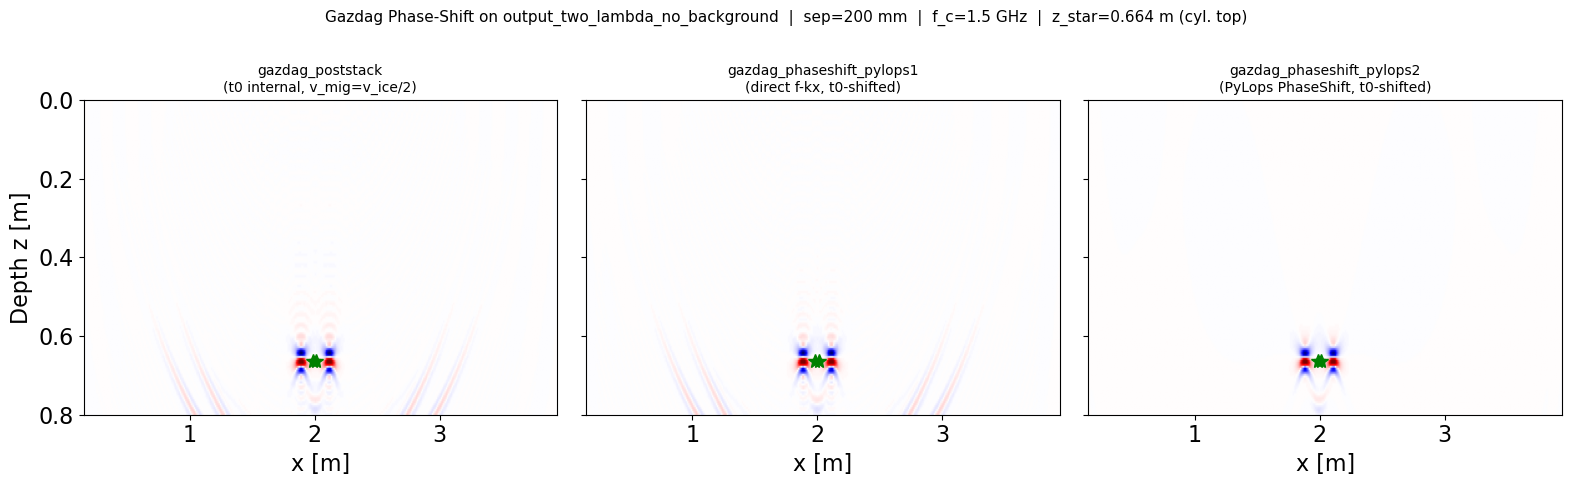

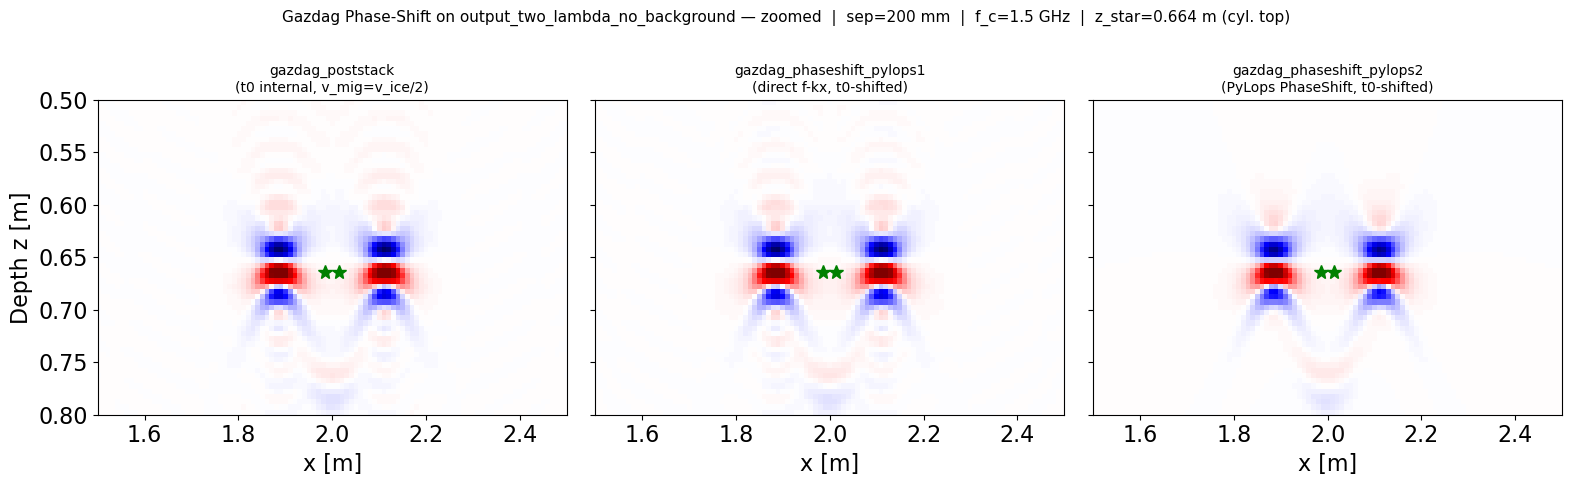

In [104]:
# ── Gazdag on output_two_lambda_no_background ────────────────────────────────
# Reuses _data_tapered, _shifted_2lam, x_traces_2lam, z_img_2lam, z_star_2lam
# from the Kirchhoff cell above.

# gazdag_poststack  : (n_tr, n_t), v_mig=v_ice/2, t0 internal
# gazdag_phaseshift_pylops1/2 : (n_t, n_tr), t0-shifted, uses v_ice

_data_T_2lam    = _data_tapered.T.copy()      # (n_t, n_tr) — unshifted
_shifted_T_2lam = _shifted_2lam.T.copy()      # (n_t, n_tr) — t0-shifted

# ── Run three schemes ─────────────────────────────────────────────────────────
print('── gazdag_poststack ────────────────────────────────────')
_t = _time.perf_counter()
gz_das_2lam = gazdag_poststack(
    _data_tapered, dt_ns_2lam,
    x_traces_2lam, v_mig, x_traces_2lam, z_img_2lam, t0_ns
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_das_2lam.shape}')

print('── gazdag_phaseshift_pylops1 ───────────────────────────')
_t = _time.perf_counter()
gz_ps1_2lam = gazdag_phaseshift_pylops1(
    _shifted_T_2lam, x_traces_2lam, time_ns_2lam, z_img_2lam, v_ice
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_ps1_2lam.shape}')

print('── gazdag_phaseshift_pylops2 ───────────────────────────')
_t = _time.perf_counter()
gz_ps2_2lam = gazdag_phaseshift_pylops2(
    _shifted_T_2lam, x_traces_2lam, time_ns_2lam, z_img_2lam, v_ice
)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={gz_ps2_2lam.shape}')

# ── Plot ──────────────────────────────────────────────────────────────────────
_gz_methods_2lam = [
    (gz_das_2lam,  'gazdag_poststack\n(t0 internal, v_mig=v_ice/2)'),
    (gz_ps1_2lam,  'gazdag_phaseshift_pylops1\n(direct f-kx, t0-shifted)'),
    (gz_ps2_2lam,  'gazdag_phaseshift_pylops2\n(PyLops PhaseShift, t0-shifted)'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                     '_zoomed'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (img, label) in zip(axes, _gz_methods_2lam):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1], z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' — zoomed' if tag else ''
    fig.suptitle(
        f'Gazdag Phase-Shift on output_two_lambda_no_background{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m (cyl. top)',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'gazdag_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


# Least Squares Migration

Building Kirchhoff operator ...
d.shape: (1611580,) K dimension: (1611580, 60800)
  K shape : (1611580, 60800)   built in 2.1 s
  d_lsm : (1611580,)

(1) Adjoint  shape=(160, 380)  peak=2.341e+01

(2) LSQR  damp=7e-01  iter_lim=20
  Done in 14.5 s  stop=0.06053204486505114  itn=20  residual=6.057e-02
  Lipschitz constant: ||K||^2 ~ 1.721e+05   alpha = 5.812e-06

(3) FISTA  eps=1.873e-01 (1% adjoint peak)  niter=50
  Done in 43.7 s   shape=(160, 380)

  Data residual ||Km - d||:
    Adjoint : 4.984e+04
    LSQR    : 6.053e-02
    FISTA   : 7.014e-02


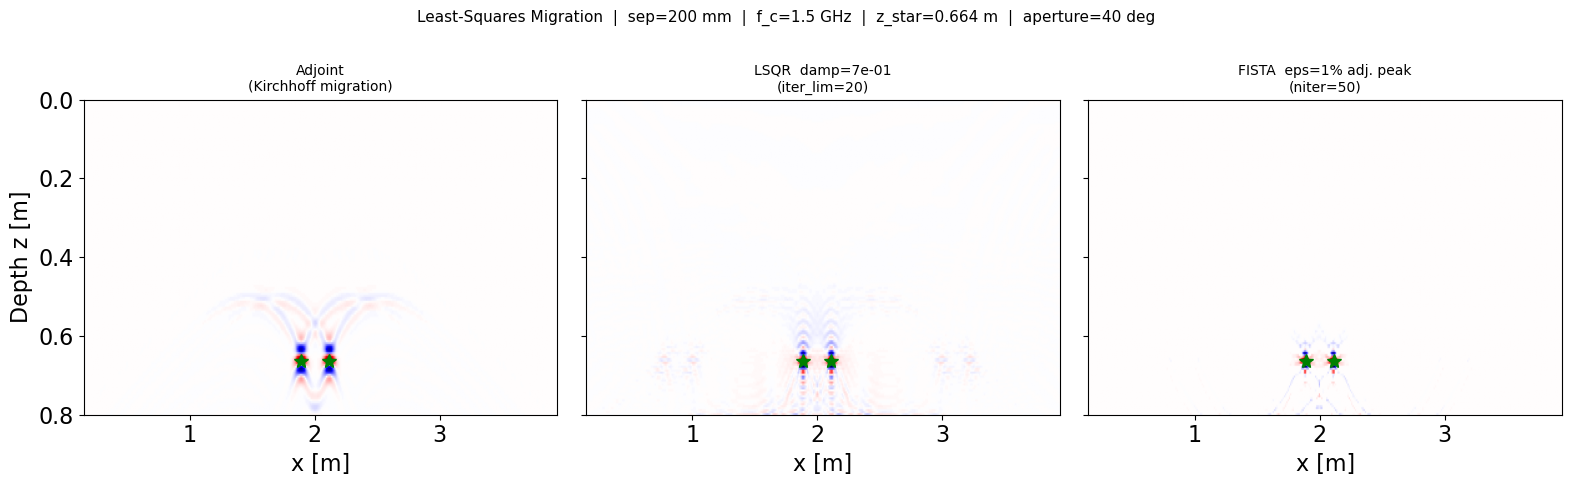

Saved: lsm_two_lambda_no_bg.png


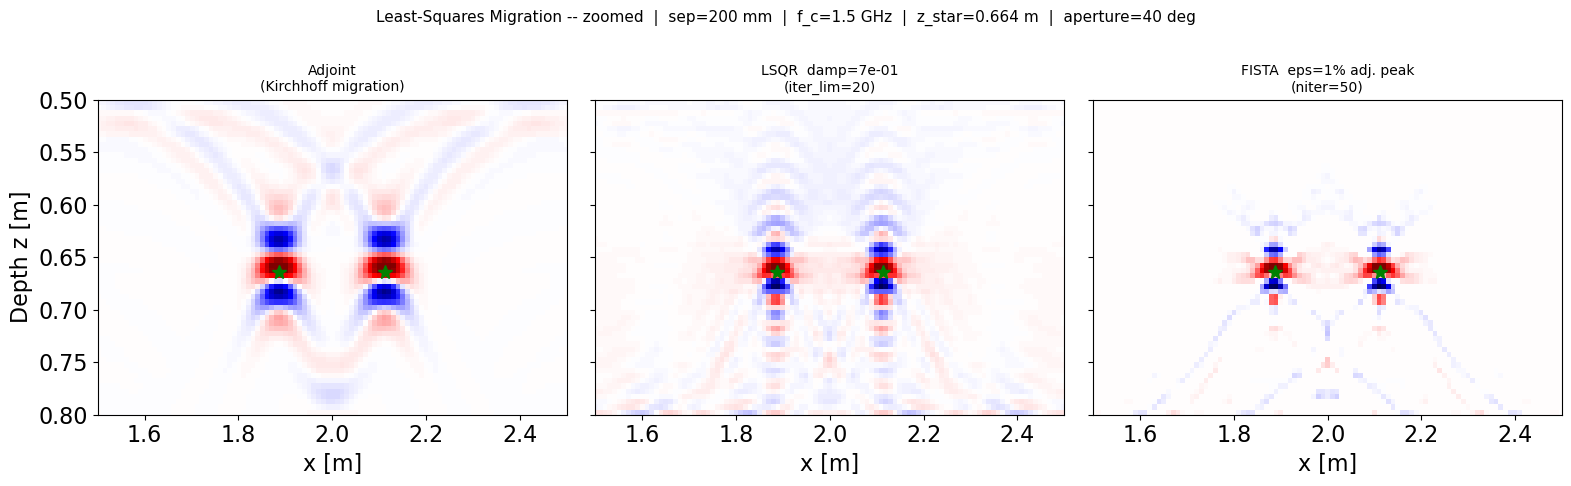

Saved: lsm_two_lambda_no_bg_zoomed.png


In [18]:
# -- Least-Squares Migration on _shifted_T_2lam ---------------------------
# _shifted_T_2lam shape: (n_t, n_tr) -- t0-shifted + tapered ZO B-scan.
# The Kirchhoff operator expects (n_tr, n_t) row-major, so we work with
# _shifted_2lam (= _shifted_T_2lam.T) for flattening; same underlying data.
#
# Three solvers:
#   (1) Adjoint  -- K^H d              (Kirchhoff migration, baseline)
#   (2) LSQR     -- min ||Km-d||^2 + damp^2||m||^2  (Tikhonov)
#   (3) FISTA    -- min ||Km-d||^2 + eps*||m||_1    (sparse)
#
# Without regularisation LSQR/FISTA fit ALL the data -- including noise and
# components outside the model space -- spreading them as image artefacts.
# eps for FISTA is calibrated relative to the adjoint image peak so it
# remains meaningful regardless of the absolute data amplitude.

import pylops
from scipy.sparse.linalg import lsqr as sp_lsqr
import time as _time

nx_lsm = len(x_traces_2lam)
nz_lsm = len(z_img_2lam)

# -- Build zero-offset Kirchhoff operator ---------------------------------
print('Building Kirchhoff operator ...')
_t = _time.perf_counter()
m_adj_raw, lsm_K = PylopsKirchoffMigration(
    _shifted_2lam, time_ns_2lam, x_traces_2lam,
    v_ice, z_img_2lam,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True,
)
print(f'  K shape : {lsm_K.shape}   built in {_time.perf_counter()-_t:.1f} s')

# Data vector -- flatten (n_tr, n_t) row-major, same order K was built with
d_lsm = _shifted_2lam.flatten()
print(f'  d_lsm : {d_lsm.shape}')

# -- (1) Adjoint migration  -----------------------------------------------
# PylopsKirchoffMigration already computed K^H d; reuse the returned image.
m_adj_lsm    = m_adj_raw   # (nz, nx)
adjoint_peak = np.max(np.abs(m_adj_lsm))
print(f'\n(1) Adjoint  shape={m_adj_lsm.shape}  peak={adjoint_peak:.3e}')

# -- (2) LSQR with Tikhonov damping ---------------------------------------
# Solves  min ||Km - d||^2 + damp^2 ||m||^2
# Damping suppresses energy in poorly-illuminated model regions and prevents
# the solver from fitting data noise.  Tune: larger -> smoother image.
LSQR_DAMP  = 7e-1    # tune here (try 1e-2 ... 1.0)
LSQR_ITERS = 20

print(f'\n(2) LSQR  damp={LSQR_DAMP:.0e}  iter_lim={LSQR_ITERS}')
_t = _time.perf_counter()
lsqr_result = sp_lsqr(lsm_K, d_lsm, iter_lim=LSQR_ITERS, damp=LSQR_DAMP, show=False)
m_lsqr = lsqr_result[0].reshape(nx_lsm, nz_lsm).T   # (nz, nx)
print(f'  Done in {_time.perf_counter()-_t:.1f} s  stop={lsqr_result[3]}'
      f'  itn={lsqr_result[2]}  residual={lsqr_result[4]:.3e}')

# Compute Lipschitz constant once via power iteration (avoids ARPACK).
np.random.seed(42)
_x_pr = np.random.randn(nx_lsm * nz_lsm)
_x_pr /= np.linalg.norm(_x_pr)
for _ in range(20):
    _x_pr = lsm_K.H @ (lsm_K @ _x_pr)
    _lip  = np.linalg.norm(_x_pr)
    _x_pr /= (_lip + 1e-30)
alpha_fista = 1.0 / _lip
print(f'  Lipschitz constant: ||K||^2 ~ {_lip:.3e}   alpha = {alpha_fista:.3e}')

# -- (3) FISTA with L1 sparsity -------------------------------------------
# Solves  min ||Km - d||^2 + eps * ||m||_1
# eps is set as a fraction of the adjoint peak so it scales with amplitude.
# Tune EPS_FRAC: larger -> sparser (stronger artefact suppression).
EPS_FRAC    = 0.008    # tune here (try 0.01 ... 0.2)
FISTA_ITERS = 50
eps_fista   = EPS_FRAC * adjoint_peak

print(f'\n(3) FISTA  eps={eps_fista:.3e} ({EPS_FRAC*100:.0f}% adjoint peak)  niter={FISTA_ITERS}')
_t = _time.perf_counter()
fista_result = pylops.optimization.sparsity.fista(
    lsm_K, d_lsm,
    niter=FISTA_ITERS,
    eps=eps_fista,
    alpha=alpha_fista,      # power iterations to estimate Lipschitz constant
    show=False,
)
m_fista = fista_result[0].reshape(nx_lsm, nz_lsm).T   # (nz, nx)
print(f'  Done in {_time.perf_counter()-_t:.1f} s   shape={m_fista.shape}')

# -- Data residuals -------------------------------------------------------
res_adj  = np.linalg.norm(d_lsm - lsm_K @ m_adj_lsm.T.ravel())
res_lsqr = np.linalg.norm(d_lsm - lsm_K @ m_lsqr.T.ravel())
res_fist = np.linalg.norm(d_lsm - lsm_K @ m_fista.T.ravel())
print(f'\n  Data residual ||Km - d||:')
print(f'    Adjoint : {res_adj:.3e}')
print(f'    LSQR    : {res_lsqr:.3e}')
print(f'    FISTA   : {res_fist:.3e}')

# -- Plot -----------------------------------------------------------------
_lsm_panels = [
    (m_adj_lsm, 'Adjoint\n(Kirchhoff migration)'),
    (m_lsqr,    f'LSQR  damp={LSQR_DAMP:.0e}\n(iter_lim={LSQR_ITERS})'),
    (m_fista,   f'FISTA  eps={EPS_FRAC*100:.0f}% adj. peak\n(niter={FISTA_ITERS})'),
]

for xlim, zlim, tag in [
    ((x_traces_2lam[0], x_traces_2lam[-1]), (z_img_2lam[-1], z_img_2lam[0]), ''),
    ((1.5, 2.5),                             (0.8, 0.5),                      '_zoomed'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (img, label) in zip(axes, _lsm_panels):
        _p = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic',
                  vmin=-_p, vmax=_p,
                  extent=[x_traces_2lam[0], x_traces_2lam[-1],
                          z_img_2lam[-1], z_img_2lam[0]],
                  origin='upper')
        ax.set_xlim(*xlim)
        ax.set_ylim(*zlim)
        ax.plot(x_scatterer_1, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.plot(x_scatterer_2, z_star_2lam, 'g*', ms=10, zorder=5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('x [m]')
    axes[0].set_ylabel('Depth z [m]')
    zoom_label = ' -- zoomed' if tag else ''
    fig.suptitle(
        f'Least-Squares Migration{zoom_label}'
        f'  |  sep={scatterer_spacing_m*1e3:.0f} mm  |  f_c={f_c_GHz} GHz'
        f'  |  z_star={z_star_2lam:.3f} m  |  aperture={ANGLE_AP} deg',
        fontsize=11,
    )
    plt.tight_layout()
    out = STUDY_ROOT / f'lsm_two_lambda_no_bg{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29568\2762034292.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


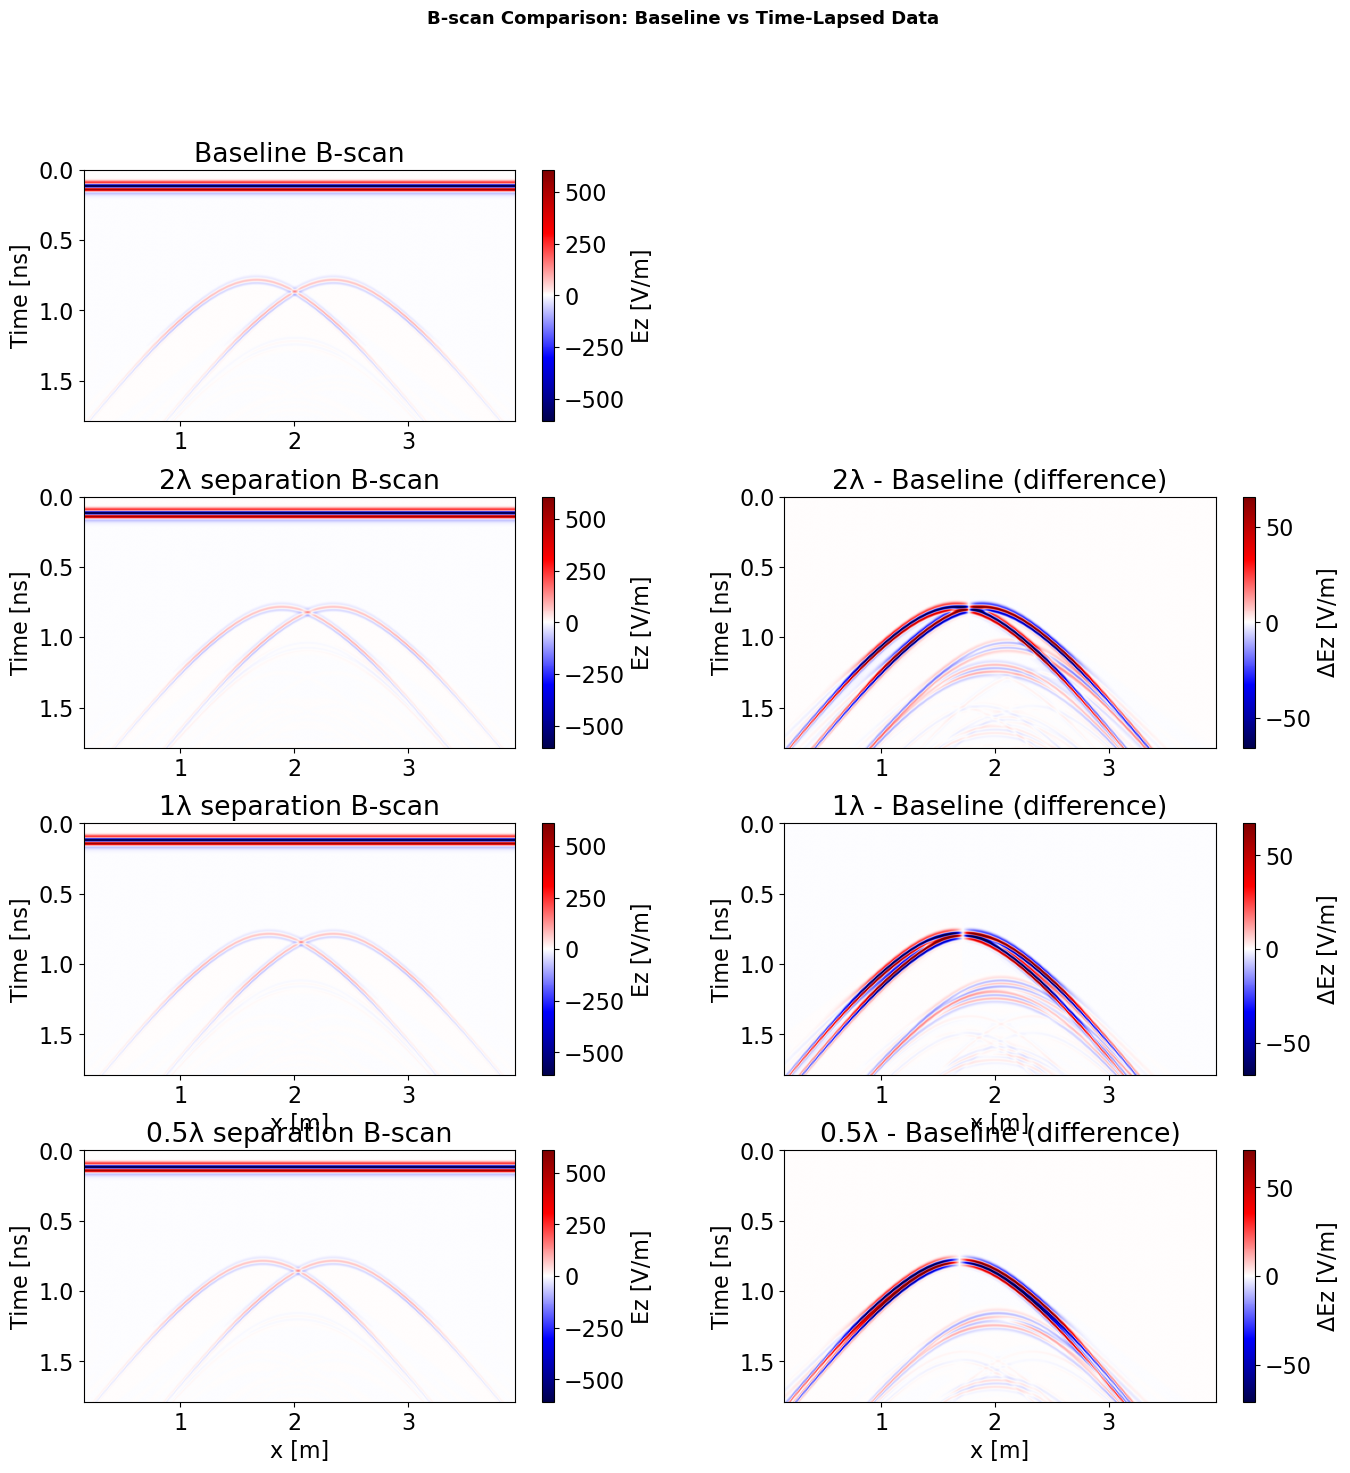

Baseline shape: (4241, 380)
2λ shape: (4241, 380)
1λ shape: (4241, 380)
0.5λ shape: (4241, 380)


In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load the three B-scans
baseline_path = 'timelapse_study/baseline/baseline_merged.out'
shift_2lam_path = 'timelapse_study/shift_2lambda/resolution_2lambda_merged.out'
shift_1lam_path = 'timelapse_study/shift_1lambda/resolution_1lambda_merged.out'
shift_0p5lam_path = 'timelapse_study/shift_0p5lambda/resolution_0p5lambda_merged.out'

baseline, dt_base = get_output_data(baseline_path, rxnumber=1, rxcomponent='Ez')
shift_2lam, dt_2lam = get_output_data(shift_2lam_path, rxnumber=1, rxcomponent='Ez')
shift_1lam, dt_1lam = get_output_data(shift_1lam_path, rxnumber=1, rxcomponent='Ez')
shift_0p5lam, dt_0p5lam = get_output_data(shift_0p5lam_path, rxnumber=1, rxcomponent='Ez')

# Time axes
time_base = np.arange(baseline.shape[1]) * dt_base
time_2lam = np.arange(shift_2lam.shape[1]) * dt_2lam
time_1lam = np.arange(shift_1lam.shape[1]) * dt_1lam
time_0p5lam = np.arange(shift_0p5lam.shape[1]) * dt_0p5lam

# Calculate differences (relative to baseline)
diff_2lam = shift_2lam - baseline[:, :shift_2lam.shape[1]]
diff_1lam = shift_1lam - baseline[:, :shift_1lam.shape[1]]
diff_0p5lam = shift_0p5lam - baseline[:, :shift_0p5lam.shape[1]]

# Create comparison figure
fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.3, wspace=0.3)

# Row 1: Baseline B-scans
ax = fig.add_subplot(gs[0, 0])
vmin, vmax = np.percentile(np.abs(baseline), [1, 99.5])
im = ax.imshow(baseline, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_base[-1]*1e9, 0],
               origin='upper')
ax.set_ylabel('Time [ns]')
ax.set_title('Baseline B-scan')
plt.colorbar(im, ax=ax, label='Ez [V/m]')

# Row 2: 2-lambda B-scans
ax = fig.add_subplot(gs[1, 0])
vmin, vmax = np.percentile(np.abs(shift_2lam), [1, 99.5])
im = ax.imshow(shift_2lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_2lam[-1]*1e9, 0],
               origin='upper')
ax.set_ylabel('Time [ns]')
ax.set_title('2λ separation B-scan')
plt.colorbar(im, ax=ax, label='Ez [V/m]')

ax = fig.add_subplot(gs[1, 1])
vmin, vmax = np.percentile(np.abs(diff_2lam), [1, 99.5])
im = ax.imshow(diff_2lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_2lam[-1]*1e9, 0],
               origin='upper')
ax.set_ylabel('Time [ns]')
ax.set_title('2λ - Baseline (difference)')
plt.colorbar(im, ax=ax, label='ΔEz [V/m]')



# Row 3: 1-lambda B-scans
ax = fig.add_subplot(gs[2, 0])
vmin, vmax = np.percentile(np.abs(shift_1lam), [1, 99.5])
im = ax.imshow(shift_1lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_1lam[-1]*1e9, 0],
               origin='upper')
ax.set_xlabel('x [m]')
ax.set_ylabel('Time [ns]')
ax.set_title('1λ separation B-scan')
plt.colorbar(im, ax=ax, label='Ez [V/m]')

ax = fig.add_subplot(gs[2, 1])
vmin, vmax = np.percentile(np.abs(diff_1lam), [1, 99.5])
im = ax.imshow(diff_1lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_1lam[-1]*1e9, 0],
               origin='upper')
ax.set_xlabel('x [m]')
ax.set_ylabel('Time [ns]')
ax.set_title('1λ - Baseline (difference)')
plt.colorbar(im, ax=ax, label='ΔEz [V/m]')

# Row 4: 0.5-lambda B-scans
ax = fig.add_subplot(gs[3, 0])
vmin, vmax = np.percentile(np.abs(shift_0p5lam), [1, 99.5])
im = ax.imshow(shift_0p5lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_0p5lam[-1]*1e9, 0],
               origin='upper')
ax.set_xlabel('x [m]')
ax.set_ylabel('Time [ns]')
ax.set_title('0.5λ separation B-scan')
plt.colorbar(im, ax=ax, label='Ez [V/m]')

ax = fig.add_subplot(gs[3, 1])
vmin, vmax = np.percentile(np.abs(diff_0p5lam), [1, 99.5])
im = ax.imshow(diff_0p5lam, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
               extent=[x_traces_2lam[0], x_traces_2lam[-1], time_0p5lam[-1]*1e9, 0],
               origin='upper')
ax.set_xlabel('x [m]')
ax.set_ylabel('Time [ns]')
ax.set_title('0.5λ - Baseline (difference)')
plt.colorbar(im, ax=ax, label='ΔEz [V/m]')


fig.suptitle('B-scan Comparison: Baseline vs Time-Lapsed Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'bscan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline shape: {baseline.shape}')
print(f'2λ shape: {shift_2lam.shape}')
print(f'1λ shape: {shift_1lam.shape}')
print(f'0.5λ shape: {shift_0p5lam.shape}')